In [9]:
import torch
import numpy as np
from tqdm.auto import tqdm
import lovely_tensors as lt
lt.monkey_patch()
import matplotlib.pyplot as plt

import os, sys
import seaborn as sns
sys.path.append('/home/ubuntu/repos/normative-diffusion')
os.chdir('/home/ubuntu/repos/normative-diffusion')

from accelerate import Accelerator, DistributedDataParallelKwargs
from sklearn.metrics import average_precision_score

from diffusion_jai import *
from modules import *
from utils import *

# add manual argparse without any command line arguments
class BraTSArgs:
    dataset_path = 'data/brats'
    path_to_csv = 'data/brats/splits/scans_val_small.csv'
    batch_size = 1
    image_size = 128

class ShiftsArgs:
    dataset_path = 'data/shifts_registered/patients'
    path_to_csv = 'data/shifts_registered/shifts_in.csv'
    batch_size = 1
    image_size = 128

bratsargs = BraTSArgs()
shiftsargs = ShiftsArgs()

args = bratsargs # to get brats datapoint


In [10]:
dataloader = MRI_Volume(bratsargs, hist=False, shift=False)
brats_vol = next(iter(dataloader))

In [11]:
kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device=device)
# ckpt = torch.load(
#     "data/brats/models/DDPM-Gauss/232_ema_ckpt.pt" # Gaussian noise
#     # "data/brats/models/DDPM-Pyramid/232_ema_ckpt.pt" # Pyramidal noise
# )

# model.load_state_dict(ckpt)
# model.eval()
args = bratsargs
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
dataloader = MRI_Volume(args, hist=False, shift=False)
dataloader = accelerator.prepare(dataloader)


In [12]:
MODEL_TYPE = ['DDPM-Gauss', 'DDPM-Pyramid'][::-1]
PYRAMID_FORWARD_NOISE = [False, True][::-1]
SKIP_DIFF = [False, True]
SKIP_NUM = [2, 5, 10, 25, 50, 100, 200, 500]

from itertools import product

zs_list_dict = {}
real_chain_list_dict = {}
pred_chain_list_dict = {}

for skip_diff, model_type, pyramid_forward_noise in tqdm(product(SKIP_DIFF, MODEL_TYPE, PYRAMID_FORWARD_NOISE), desc='outer product'):
    print(f"skip_diff: {skip_diff}, model_type: {model_type}, pyramid_forward_noise: {pyramid_forward_noise}")
    zs_list = []
    real_chain_list = []
    pred_chain_list = []
    ckpt = torch.load(
    f"data/brats/models/{model_type}/232_ema_ckpt.pt"
    )
    model.load_state_dict(ckpt)
    model.eval()
    with torch.no_grad():
        for i, (image, label) in tqdm(enumerate(dataloader), total=len(dataloader), desc='dataloader loop'):
            # image = torch.from_numpy(match_histograms_vectorized(image.cpu().numpy(), template.numpy())).to(device).float()
            image = (image * 2) - 1
            # num_steps = 200
            size_splits = 20
            num_volumes = image.shape[0]
            num_slices = image.shape[4]
            image = torch.permute(image, (0, 4, 1, 2, 3))
            image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
            splits = torch.split(image, size_splits)
            chunks = []
            for split_tensor in tqdm(splits, total=len(splits), desc='split loop'):
                if not skip_diff:
                    real_chain, pred_chain = diffusion.dpm_differences(model, split_tensor, start = 0, stop = 300, pyramid=pyramid_forward_noise, return_chain=True)
                    real_chain, pred_chain = real_chain.to('cpu'), pred_chain.to('cpu')
                else:
                    real_chain, pred_chain = diffusion.skip_differences(model, split_tensor, start = 0, stop = 300, skip=25, pyramid=pyramid_forward_noise, return_chain=True)
                    real_chain, pred_chain = real_chain.to('cpu'), pred_chain.to('cpu')
                chunks.append([real_chain, pred_chain])
            # zs = torch.cat([chunk[0] for chunk in chunks], dim=0)
            real_chain = torch.cat([chunk[0] for chunk in chunks], dim=0)
            pred_chain = torch.cat([chunk[1] for chunk in chunks], dim=0)
            # zs_list.append(zs)
            real_chain_list.append(real_chain)
            pred_chain_list.append(pred_chain)
            break # only 1 datapoint

    zs_list_dict[(skip_diff, model_type, pyramid_forward_noise)] = zs_list
    real_chain_list_dict[(skip_diff, model_type, pyramid_forward_noise)] = real_chain_list
    pred_chain_list_dict[(skip_diff, model_type, pyramid_forward_noise)] = pred_chain_list

    break # only 1 config



outer product: 0it [00:00, ?it/s]

skip_diff: False, model_type: DDPM-Pyramid, pyramid_forward_noise: True


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]


dataloader loop:   0%|          | 0/9 [02:27<?, ?it/s]
outer product: 0it [02:27, ?it/s]


In [16]:
# brats_real = real_chain[100, :, 0, 18:114, 18:114]
# brats_real = real_chain[100, :, 0, 18:114, 18:114]
brats_pred = pred_chain[100, :, 0]
brats_real = real_chain[100, :, 0]
# print(image_.shape)
# image = image_[0].permute(3, 0, 1, 2)

In [17]:
image.shape

torch.Size([155, 4, 128, 128])

In [20]:
brats_real.shape, brats_pred.shape

(torch.Size([299, 128, 128]), torch.Size([299, 128, 128]))

In [7]:
print(image.shape, image.device)
xt, noise = diffusion.noise_images(image[100:101], torch.tensor([100]).long().to(image.device), pyramid=False)
xt_pyr, noise_pyr = diffusion.noise_images(image[100:101], torch.tensor([100]).long().to(image.device), pyramid=True)

xt = xt[..., 18:114, 18:114]
noise = noise[..., 18:114, 18:114]
xt_pyr = xt_pyr[..., 18:114, 18:114]
noise_pyr = noise_pyr[..., 18:114, 18:114]


# plot image, xt and noise in 1x3 grid
print(image.shape, xt.shape, noise.shape, image[100, 0 :, :].max(), xt.max(), noise.max())
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(image[100, 0, 18:114, 18:114].T.cpu(), cmap='gray')
axes[0].set_title('Image')
axes[1].imshow(xt[0, 0, :, :].T.cpu(), cmap='gray')
axes[1].set_title('xt')
axes[2].imshow(noise[0, 0, :, :].T.cpu(), cmap='gray')
axes[2].set_title('noise')
axes[3].imshow(xt_pyr[0, 0, :, :].T.cpu(), cmap='gray')
axes[3].set_title('xt_pyr')
axes[4].imshow(noise_pyr[0, 0, :, :].T.cpu(), cmap='gray')
axes[4].set_title('noise_pyr')
# remove axes
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig('plots/fig1_brats_image_xt_noise.pdf', dpi=300)
plt.show()


NameError: name 'image' is not defined

In [31]:
xt_pyr, noise_pyr = diffusion.noise_images(image[100:101], torch.tensor([100]).long().to(image.device), pyramid=True)


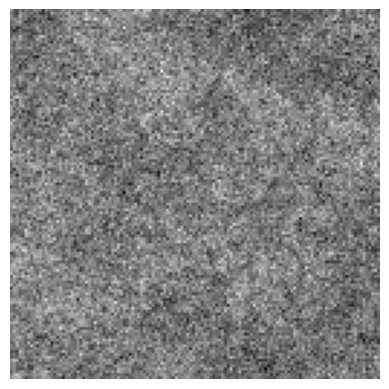

In [36]:
plt.imshow(noise_pyr[0,0].cpu(), cmap='gray')
# remove axes
plt.axis('off')
plt.savefig('plots/fig1_brats_noise_pyr.pdf', dpi=300)

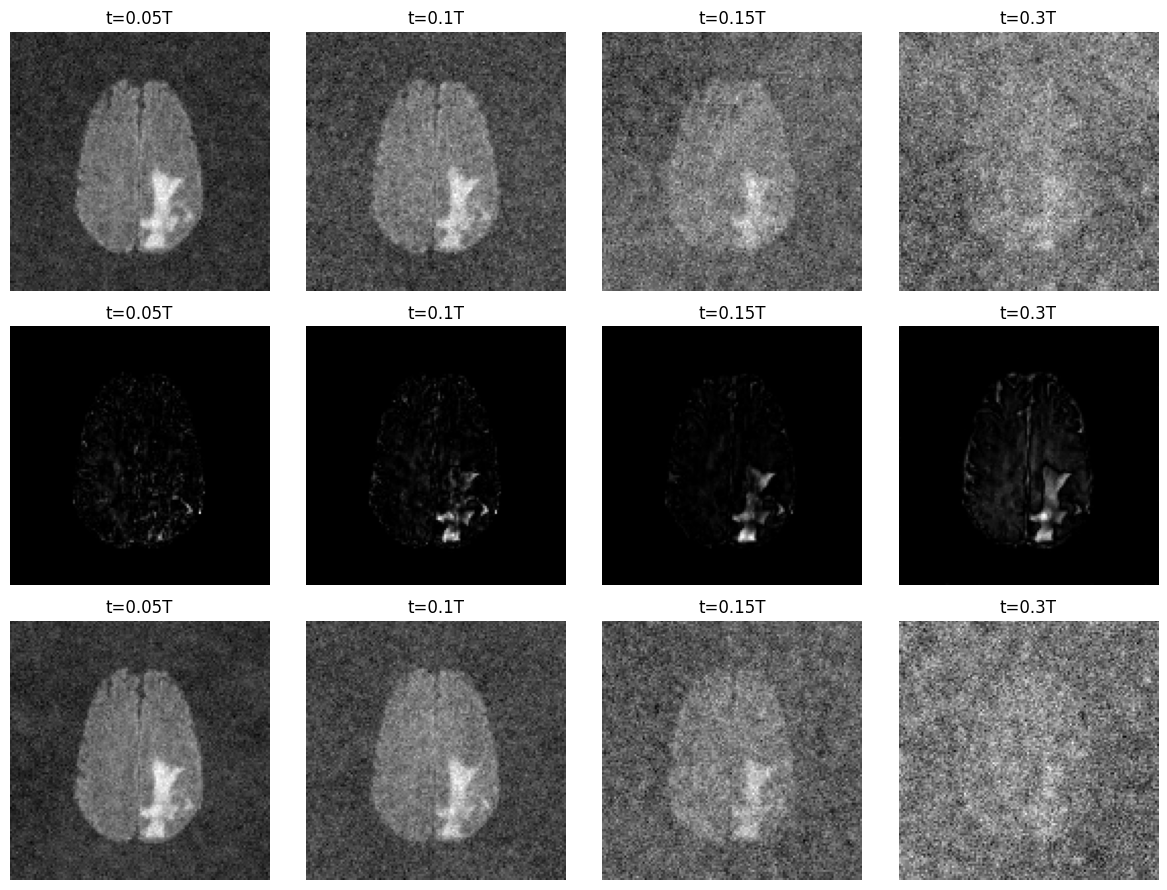

In [28]:
# create a 3x4 figure with im subplots
fig, ax = plt.subplots(3, 4, figsize=(12, 9))
# fig.suptitle('Brats')
for i, row in enumerate(ax):
    if i == 0:
        x1, x2, x3, x4 = brats_pred[50], brats_pred[80], brats_pred[150], brats_pred[-1]
    elif i == 2:
        x1, x2, x3, x4 = brats_real[50-1], brats_real[80-1], brats_real[150-1], brats_real[-1-1]
    else:
        x1 = (brats_real[50] - brats_pred[50]).abs()**2
        x2 = (brats_real[80] - brats_pred[80]).abs()**2
        x3 = (brats_real[150] - brats_pred[150]).abs()**2
        x4 = (brats_real[-1] - brats_pred[-1]).abs()**2
    
    row[0].imshow(x1.T, cmap='gray')
    row[1].imshow(x2.T, cmap='gray')
    row[2].imshow(x3.T, cmap='gray')
    row[3].imshow(x4.T, cmap='gray')
    row[0].set_xticks([])
    row[0].set_yticks([])
    row[1].set_xticks([])
    row[1].set_yticks([])
    row[2].set_xticks([])
    row[2].set_yticks([])
    row[3].set_xticks([])
    row[3].set_yticks([])
    # titles
    row[0].set_title('t=0.05T')
    row[1].set_title('t=0.1T')
    row[2].set_title('t=0.15T')
    row[3].set_title('t=0.3T')
    for rowi in row:
        rowi.axis('off')

fig.tight_layout()
plt.savefig('plots/fig1_brats_pyr.pdf', dpi=300)

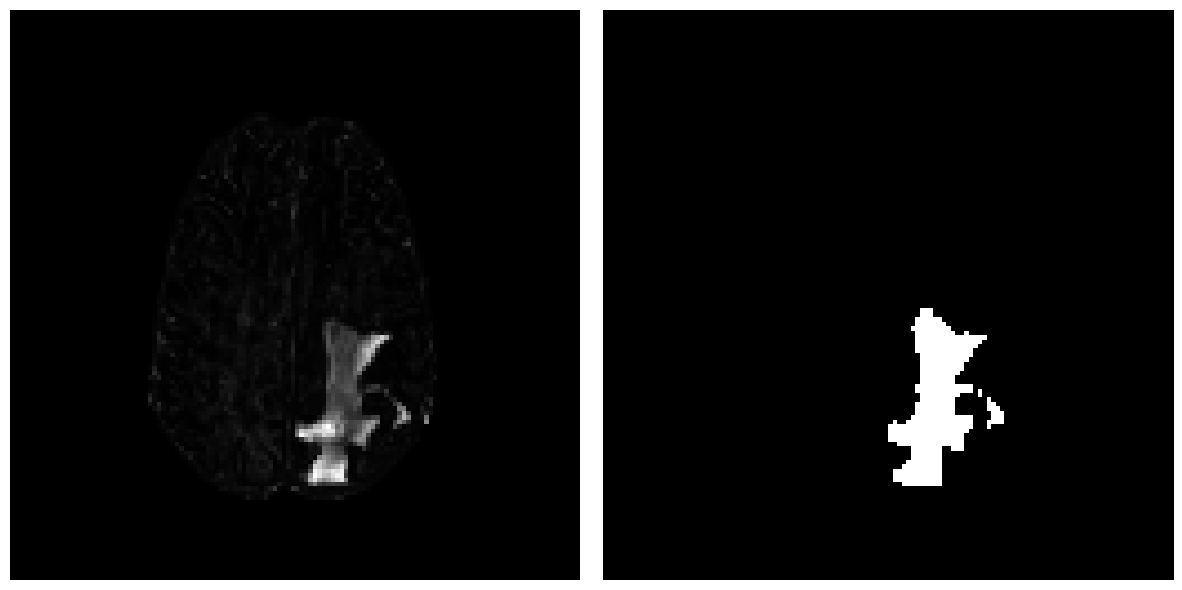

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ano = ((brats_real - brats_pred).abs()**2)[75:200].mean(dim=0)
ax[0].imshow(ano.T, cmap='gray')
ax[0].axis('off')

# ax[1].imshow(label.cpu().numpy()[0,18:114,18:114,100].T, cmap='gray')
ax[1].imshow(label.cpu().numpy()[0,:,:,100].T, cmap='gray')
ax[1].axis('off')

fig.tight_layout()
plt.savefig('plots/fig1_brats_ano_label_pyr.pdf', dpi=300)
plt.show()
# print(label.cpu().numpy()[0,:,:,100].shape)

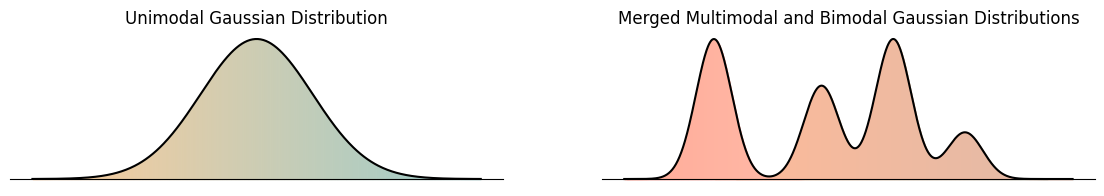

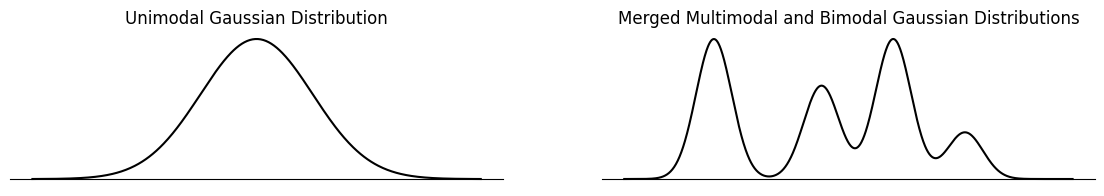

In [61]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_fill(x, y, color1, color2, ax, alpha=0.7):
    n = len(x)
    for i in range(n - 1):
        z = i / (n - 1)
        color = (1 - z) * np.array(color1) + z * np.array(color2)
        ax.fill_between(x[i:i + 2], y[i:i + 2], color=color, alpha=alpha)

def merge_and_plot(x1, y1, x2, y2, color1, color2, ax, alpha=0.7):
    x_merged = np.sort(np.concatenate([x1, x2]))
    y_merged_1 = np.interp(x_merged, x1, y1)
    y_merged_2 = np.interp(x_merged, x2, y2)
    y_blended = y_merged_1 + y_merged_2 - offset
    gradient_fill(x1, y1, color1[0], color1[1], ax, alpha)
    gradient_fill(x2, y2, color2[0], color2[1], ax, alpha)
    ax.fill_between(x_merged, y_blended, color=color_blended, alpha=alpha)

def generate_plots(filename, fill=True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 2))
    alpha_value = 0.7 if fill else 0
    axes[0].plot(x1, y1, color='black')
    if fill:
        gradient_fill(x1, y1, pastel_orange, pastel_teal, axes[0], alpha=alpha_value)
    axes[0].set_title('Unimodal Gaussian Distribution')
    axes[1].plot(x_merged, y_blended, color='black')
    if fill:
        merge_and_plot(x2, y2, x3, y3, [pastel_orange, pastel_teal], [pastel_red, pastel_pink], axes[1], alpha=alpha_value)
    axes[1].set_title('Merged Multimodal and Bimodal Gaussian Distributions')
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.yaxis.set_ticks([])
        ax.xaxis.set_ticks([])
        ax.spines['bottom'].set_position('zero')
    plt.savefig(f"plots/{filename}.svg")

# Data generation for the plots
offset = 0.0
x1 = np.linspace(-4, 4, 500)
x2 = np.linspace(-10, 10, 1000)
x3 = np.linspace(-15, -5, 500)
y1 = 0.4 * np.exp(-0.5 * (x1)**2) + offset
y2 = (0.2 * np.exp(-0.5 * (x2 + 4)**2) + 0.3 * np.exp(-0.5 * (x2)**2) + 0.1 * np.exp(-0.5 * (x2 - 4)**2)) + offset
# y3 = (0.2 * np.exp(-0.5 * (x3 + 10)**2) + 0.1 * np.exp(-0.5 * (x3 + 8)**2)) + offset
y3 = (0.3 * np.exp(-0.5 * (x3 + 10)**2)) + offset
x_merged = np.sort(np.concatenate([x2, x3]))
y_merged_1 = np.interp(x_merged, x2, y2)
y_merged_2 = np.interp(x_merged, x3, y3)
y_blended = y_merged_1 + y_merged_2 - offset

# Pastel gradient colors
pastel_orange = np.array([1, 0.8, 0.6])
pastel_teal = np.array([0.6, 0.8, 0.8])
pastel_red = np.array([1, 0.6, 0.6])
pastel_pink = np.array([1, 0.8, 0.8])
color_blended = 0.5 * (pastel_orange + pastel_red)

# Generate the PDFs
generate_plots("gaussian_distributions_with_fill", True)
generate_plots("gaussian_distributions_without_fill", False)

In [127]:

def pyramidal(n, channels, device, image_size=128, discount=0.8):
    u = transforms.Resize(image_size, antialias=True)
    noise = torch.randn((n, channels, image_size, image_size)).to(device)
    noises = [noise.clone()]
    w = image_size
    h = image_size
    for i in range(10):
        r = random.random() * 2 + 2  # Rather than always going 2x,
        w, h = max(1, int(w / (r**i))), max(1, int(h / (r**i)))
        extra_noise = u(torch.randn(n, channels, w, h).to(device))
        noise += extra_noise * discount**i
        noises.append(extra_noise * discount**i)
        if w == 1 or h == 1:
            break  # Lowest resolution is 1x1
    return noise / noise.std(), noises  # Scaled back to roughly unit variance

total_pyr, pyr = pyramidal(1, 1, 'cpu', image_size=128, discount=0.8)

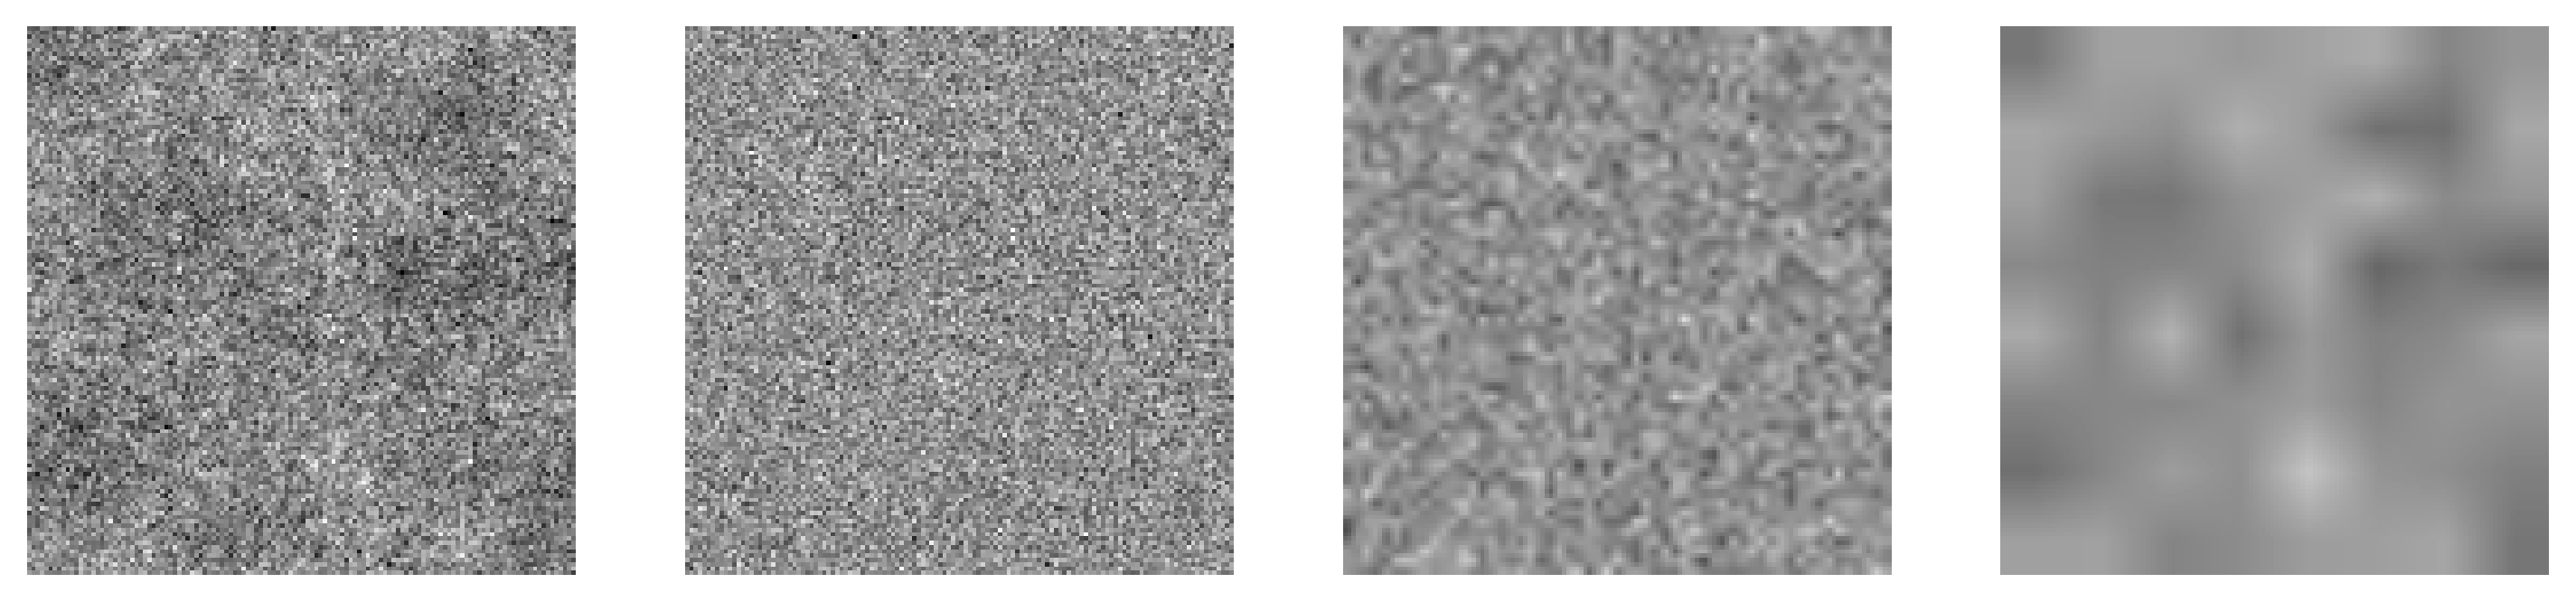

In [144]:
import matplotlib.pyplot as plt

# Create a 1x4 figure
fig, axs = plt.subplots(1, 4, figsize=(12, 3), dpi=300)

axs[0].imshow(total_pyr.squeeze(), cmap='gray')
axs[0].axis('off')

# Plot each tensor in grayscale
for i, j in enumerate([0, 2, 3]):
    axs[i+1].imshow(pyr[j].squeeze(), cmap='gray', vmin = pyr[0].min(), vmax = pyr[0].max())
    axs[i+1].axis('off')

# Save the figure as a PDF
plt.savefig('plots/pyramidal_tensors.pdf', format='pdf')
plt.show()


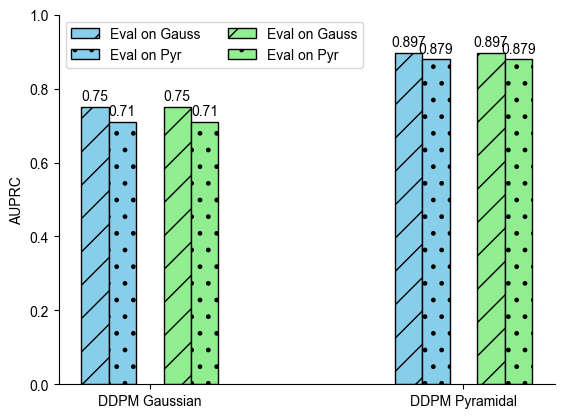

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Data from the user's table
methods = ['DDPM Gaussian', 'DDPM Pyramidal']
eval_gauss = [0.75, 0.897]
eval_pyr = [0.71, 0.879]

# Setting the positions and width for the bars
pos = np.arange(len(methods))
bar_width = 0.35

# Plotting
fig, ax = plt.subplots()

# Grouped barplot
bars1 = ax.bar(pos - bar_width/2, eval_gauss, bar_width/4, label='Eval on Gauss', hatch='/', color='skyblue', edgecolor='black')
bars2 = ax.bar(pos - bar_width/4, eval_pyr, bar_width/4, label='Eval on Pyr', hatch='.', color='skyblue', edgecolor='black')

# Grouped barplot
bars3 = ax.bar(pos + bar_width/4, eval_gauss, bar_width/4, label='Eval on Gauss', hatch='/', color='lightgreen', edgecolor='black')
bars4 = ax.bar(pos + bar_width/2, eval_pyr, bar_width/4, label='Eval on Pyr', hatch='.', color='lightgreen', edgecolor='black')

# Removing spines
sns.despine()

# Adding data labels
for bar in bars1 + bars2 + bars3 + bars4:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval,3), ha='center', va='bottom')

# Labels and title
ax.set_xticks(pos)
ax.set_xticklabels(methods)
ax.set_ylabel('AUPRC')
ax.legend(loc='upper left', ncol=2)

# Setting the y-axis limit slightly higher than the highest data point
ax.set_ylim(0, 1)

# Use Arial font
plt.rcParams['font.family'] = 'Arial'

# Set the DPI and save the figure
plt.savefig('plots/grouped_barplot.pdf', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


/tmp/ipykernel_1622855/4047851659.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])


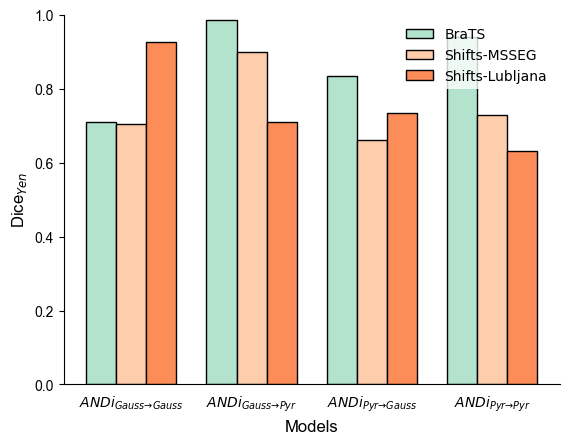

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# synthetic data
plt.rcParams['text.usetex'] = False
models = [r'$ANDi_{Gauss→Gauss}$', r'$ANDi_{Gauss→Pyr}}$', r'$ANDi_{Pyr→Gauss}}$', r'$ANDi_{Pyr→Pyr}}$']
datasets = ['BraTS', 'Shifts-MSSEG', 'Shifts-Lubljana']
# colors -- light green, light orange, dark orange
colors = ['#b3e2cd', '#fdcdac', '#fc8d59']
data = np.random.rand(3, 4)/2+0.5  # 3 datasets, 4 models

# setting the positions and width for the bars
pos = np.arange(len(models))
bar_width = 0.25

# plotting
fig, ax = plt.subplots()
for i in range(len(datasets)):
    # add borders to bars
    ax.bar(pos + i * bar_width, data[i], width=bar_width, edgecolor='k', label=datasets[i], color=colors[i])

# formatting
ax.set_xlabel('Models', fontsize=12, fontname='Arial')
ax.set_ylabel(r'Dice$_{Yen}$', fontsize=12, fontname='Arial')
ax.set_xticks(pos + bar_width)
# remove the major ticks
ax.tick_params(axis='x', which='major', bottom=False)
ax.set_xticklabels(models, fontname='Arial')
ax.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylim(0, 1.0)
ax.legend(title='')
# remove legend frame
ax.get_legend().get_frame().set_linewidth(0.0)
plt.xticks(fontsize=10, fontname='Arial')
plt.yticks(fontsize=10, fontname='Arial')
sns.despine()

# saving and displaying the plot
# plt.savefig('plots/grouped_barplot.pdf', dpi=300, format='pdf')
plt.show()


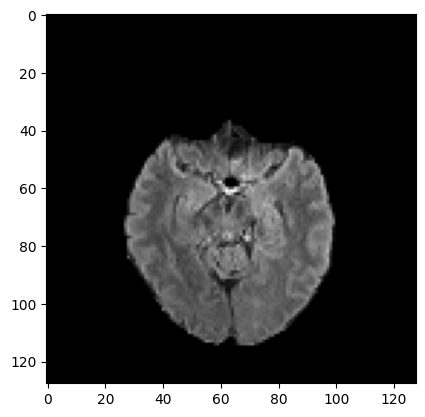

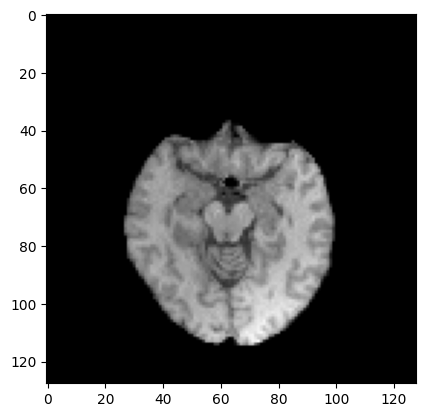

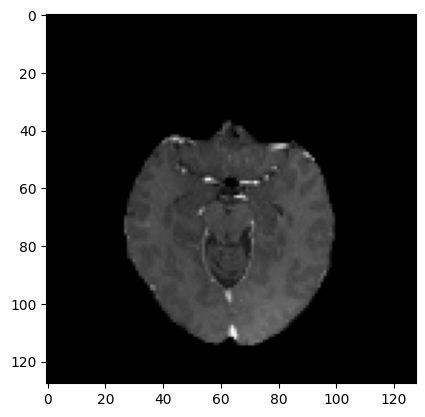

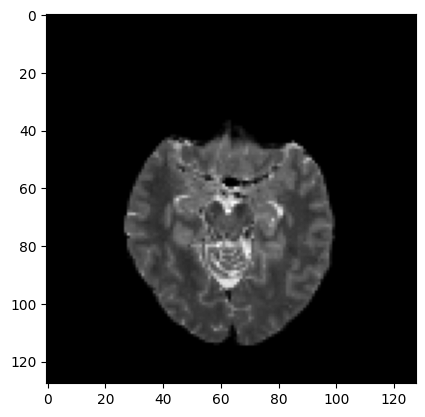

shape (4, 128, 128) 
max values per modality [1.2936187, 1.1399118, 1.8352857, 1.1541266] 
min values per modality [0.0, 0.0, 0.0, 0.0]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
slice = np.load('/home/ubuntu/slurm_work/brats_data_slices/53537.npy')
plt.imshow(slice[0, :, :].T, cmap='gray')
plt.show()
plt.imshow(slice[1, :, :].T, cmap='gray')
plt.show()
plt.imshow(slice[2, :, :].T, cmap='gray')
plt.show()
plt.imshow(slice[3, :, :].T, cmap='gray')
plt.show()
print('shape', slice.shape, '\nmax values per modality', [s.max() for s in slice], '\nmin values per modality', [s.min() for s in slice])